<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica-4/blob/main/Pr%C3%A1tica_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Sampling frequency
fs = 20000.0

# Utility function to plot frequency response (magnitude only for brevity and focus on 'r')
def plot_filter_response_q1(b, a, fs, title, r_val=None):
    w, h = signal.freqz(b, a, worN=8000, fs=fs)
    label = f'r = {r_val}' if r_val is not None else None
    plt.plot(w, 20 * np.log10(abs(h)), label=label)

# Function to design a 2nd order IIR filter with explicit pole radius 'r'
def design_and_plot_vary_r(filter_type, fc, fs, r_values=[0.7, 0.85, 0.98]):
    # Convert cutoff frequency to normalized frequency for pole angle
    if not isinstance(fc, list):
        fc_norm = fc / (fs / 2)
        # If fc is a single value (float), use it directly for poles_angle_rad
        pole_angle_for_calc = fc_norm
    else:
        fc_norm = [f / (fs / 2) for f in fc]
        # If fc is a list, use the first element for poles_angle_rad (as per original logic for single fc)
        pole_angle_for_calc = fc_norm[0]

    plt.figure(figsize=(10, 5))

    for r_val in r_values:
        # Poles angle based on cutoff frequency
        poles_angle_rad = pole_angle_for_calc * np.pi

        # Denominator coefficients (a) from pole radius and angle
        a1 = -2 * r_val * np.cos(poles_angle_rad)
        a2 = r_val**2
        a = [1, a1, a2]

        b_base = [0, 0, 0] # Initialize b coefficients
        if filter_type == 'lowpass':
            # Zeros at z=-1 for a proper lowpass
            b_base = [1, 2, 1]
            # Normalize gain at DC (z=1) to 0dB
            gain = (b_base[0] + b_base[1] + b_base[2]) / (a[0] + a[1] + a[2])
        elif filter_type == 'highpass':
            # Zeros at z=1 for a proper highpass
            b_base = [1, -2, 1]
            # Normalize gain at Nyquist (z=-1) to 0dB
            gain = (b_base[0] - b_base[1] + b_base[2]) / (a[0] - a[1] + a[2])
        elif filter_type == 'notch':
            # Zeros on the unit circle at the notch frequency
            notch_freq_norm_rad = pole_angle_for_calc * np.pi # Use pole_angle_for_calc here too
            b_base = [1, -2 * np.cos(notch_freq_norm_rad), 1]
            # Normalize gain at DC (z=1) to 0dB to pass DC frequencies
            gain = (b_base[0] + b_base[1] + b_base[2]) / (a[0] + a[1] + a[2])
        else:
            raise ValueError("Unsupported filter type.")

        b = [coeff * gain for coeff in b_base]
        plot_filter_response_q1(b, a, fs, f'{filter_type.capitalize()} Filter (fc={fc if not isinstance(fc, list) else fc[0]} Hz) with varying r', r_val=r_val)

    plt.title(f'Magnitude Response of {filter_type.capitalize()} Filter (fc={fc if not isinstance(fc, list) else fc[0]} Hz) with varying r')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude [dB]')
    plt.grid()
    plt.legend()
    plt.show()

    print(f"Comentários para o filtro {filter_type} com fc={fc if not isinstance(fc, list) else fc[0]} Hz e r variando:")
    print("À medida que o valor de 'r' (raio do polo) se aproxima de 1, a resposta em frequência do filtro torna-se mais seletiva.")
    print("Para filtros passa-baixas e passa-altas, um 'r' próximo de 1 resulta em uma transição mais abrupta da banda de passagem para a banda de rejeição.")
    print("Para o filtro Notch, um 'r' próximo de 1 resulta em uma atenuação mais profunda e uma banda de rejeição mais estreita ao redor da frequência de corte.")
    print("Valores menores de 'r' levam a uma resposta mais suave e menos seletiva (maior largura de banda de transição/rejeição).")

##### Questão 1 #####


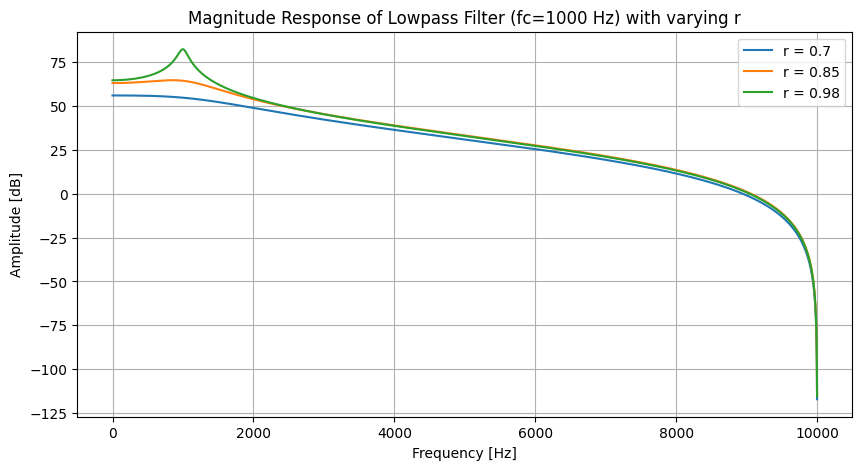

Comentários para o filtro lowpass com fc=1000 Hz e r variando:
À medida que o valor de 'r' (raio do polo) se aproxima de 1, a resposta em frequência do filtro torna-se mais seletiva.
Para filtros passa-baixas e passa-altas, um 'r' próximo de 1 resulta em uma transição mais abrupta da banda de passagem para a banda de rejeição.
Para o filtro Notch, um 'r' próximo de 1 resulta em uma atenuação mais profunda e uma banda de rejeição mais estreita ao redor da frequência de corte.
Valores menores de 'r' levam a uma resposta mais suave e menos seletiva (maior largura de banda de transição/rejeição).


/tmp/ipykernel_26446/3667090384.py:12: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), label=label)


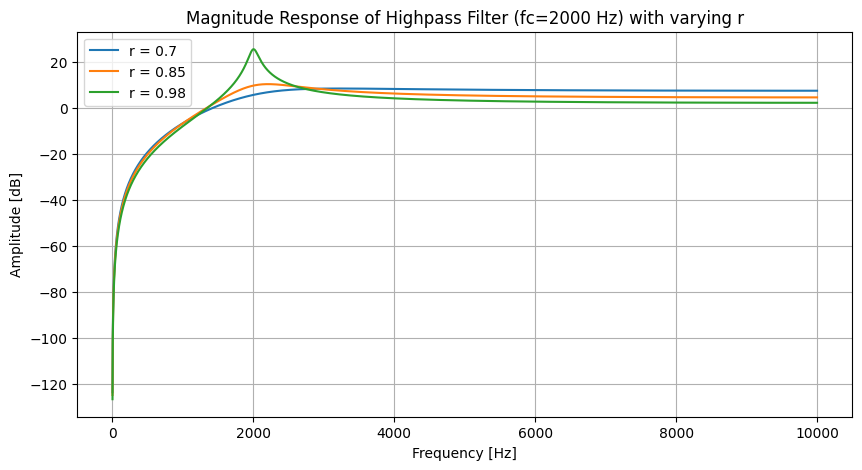

Comentários para o filtro highpass com fc=2000 Hz e r variando:
À medida que o valor de 'r' (raio do polo) se aproxima de 1, a resposta em frequência do filtro torna-se mais seletiva.
Para filtros passa-baixas e passa-altas, um 'r' próximo de 1 resulta em uma transição mais abrupta da banda de passagem para a banda de rejeição.
Para o filtro Notch, um 'r' próximo de 1 resulta em uma atenuação mais profunda e uma banda de rejeição mais estreita ao redor da frequência de corte.
Valores menores de 'r' levam a uma resposta mais suave e menos seletiva (maior largura de banda de transição/rejeição).


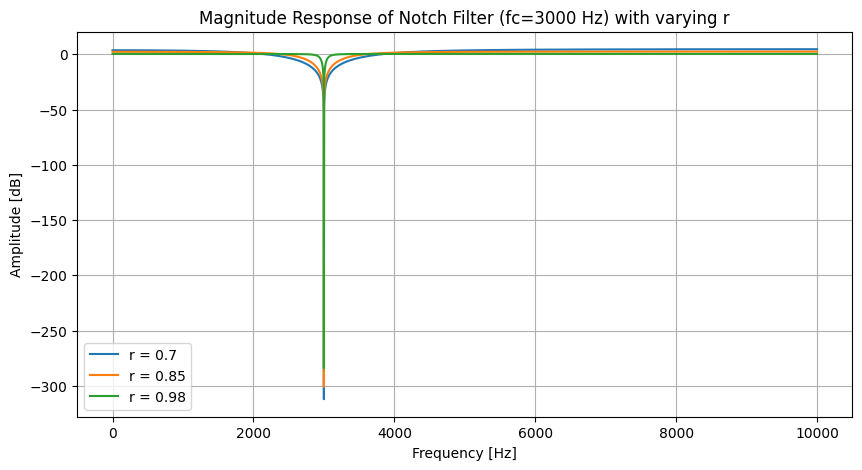

Comentários para o filtro notch com fc=3000 Hz e r variando:
À medida que o valor de 'r' (raio do polo) se aproxima de 1, a resposta em frequência do filtro torna-se mais seletiva.
Para filtros passa-baixas e passa-altas, um 'r' próximo de 1 resulta em uma transição mais abrupta da banda de passagem para a banda de rejeição.
Para o filtro Notch, um 'r' próximo de 1 resulta em uma atenuação mais profunda e uma banda de rejeição mais estreita ao redor da frequência de corte.
Valores menores de 'r' levam a uma resposta mais suave e menos seletiva (maior largura de banda de transição/rejeição).

##### Questão 2 #####


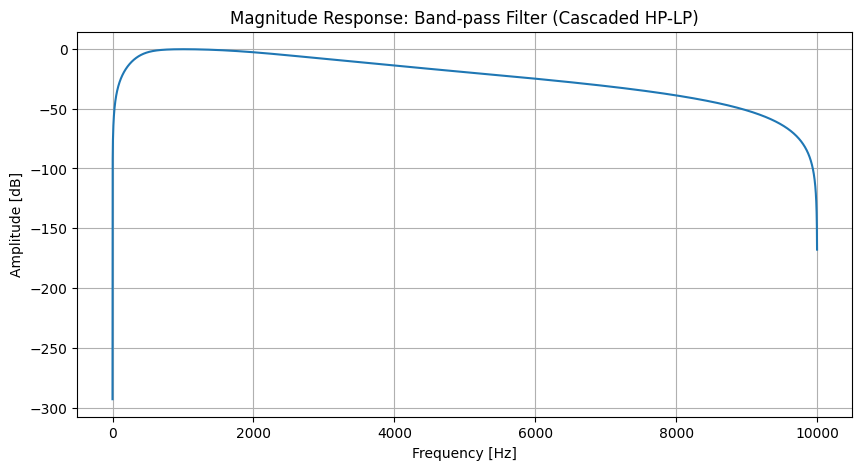

Comentários para o filtro passa-faixas (Questão 2):
Este filtro passa-faixas foi projetado pela associação em cascata de um filtro passa-altas Butterworth de 2ª ordem com fc1=500 Hz e um filtro passa-baixas Butterworth de 2ª ordem com fc2=2000 Hz.
A resposta em frequência mostra uma banda de passagem entre 500 Hz e 2000 Hz, com atenuação fora dessa faixa. A transição da banda de passagem para a banda de rejeição é relativamente suave, característica de filtros de ordem mais baixa.
A ordem total do filtro resultante da cascata é a soma das ordens dos filtros individuais (2 + 2 = 4 neste caso), o que proporciona uma seletividade maior do que um filtro de 2ª ordem isolado.

Comparação com os resultados da Questão 1:
Na Questão 1, os filtros básicos foram implementados com variação de 'r', o que nos permitiu observar como a proximidade dos polos ao círculo unitário (r~1) afeta a seletividade. Um 'r' maior resultou em transições mais abruptas e atenuações mais profundas.
Na Questão 2, ao in

In [7]:
# Questão 1:
print("##### Questão 1 #####")

# (a) Passa-baixas com fc=1000 Hz
design_and_plot_vary_r('lowpass', fc=1000, fs=fs, r_values=[0.7, 0.85, 0.98])

# (b) Passa-altas com fc=2000 Hz
design_and_plot_vary_r('highpass', fc=2000, fs=fs, r_values=[0.7, 0.85, 0.98])

# (c) Notch com fc1=3000 Hz
design_and_plot_vary_r('notch', fc=3000, fs=fs, r_values=[0.7, 0.85, 0.98])

print("\n##### Questão 2 #####")
# Questão 2: Passa-faixas com fc1=500 Hz e fc2=2000 Hz fazendo uma associação de blocos componentes básicos.

# Design a 2nd order Butterworth High-pass filter at 500 Hz
order = 2
nyq = 0.5 * fs
cutoff_hp_norm = 500 / nyq
b_hp, a_hp = signal.butter(order, cutoff_hp_norm, btype='high', analog=False)

# Design a 2nd order Butterworth Low-pass filter at 2000 Hz
cutoff_lp_norm = 2000 / nyq
b_lp, a_lp = signal.butter(order, cutoff_lp_norm, btype='low', analog=False)

# Cascade the filters: Convolve the impulse responses for 'b' and 'a'
b_bp_cascade = np.convolve(b_hp, b_lp)
a_bp_cascade = np.convolve(a_hp, a_lp)

# Plot the frequency response of the cascaded filter
w, h = signal.freqz(b_bp_cascade, a_bp_cascade, worN=8000, fs=fs)
plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Magnitude Response: Band-pass Filter (Cascaded HP-LP)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.grid()
plt.show()

print("Comentários para o filtro passa-faixas (Questão 2):")
print("Este filtro passa-faixas foi projetado pela associação em cascata de um filtro passa-altas Butterworth de 2ª ordem com fc1=500 Hz e um filtro passa-baixas Butterworth de 2ª ordem com fc2=2000 Hz.")
print("A resposta em frequência mostra uma banda de passagem entre 500 Hz e 2000 Hz, com atenuação fora dessa faixa. A transição da banda de passagem para a banda de rejeição é relativamente suave, característica de filtros de ordem mais baixa.")
print("A ordem total do filtro resultante da cascata é a soma das ordens dos filtros individuais (2 + 2 = 4 neste caso), o que proporciona uma seletividade maior do que um filtro de 2ª ordem isolado.")
print("\nComparação com os resultados da Questão 1:")
print("Na Questão 1, os filtros básicos foram implementados com variação de 'r', o que nos permitiu observar como a proximidade dos polos ao círculo unitário (r~1) afeta a seletividade. Um 'r' maior resultou em transições mais abruptas e atenuações mais profundas.")
print("Na Questão 2, ao invés de controlar 'r' explicitamente, usamos a função `signal.butter` que projeta filtros com base em uma ordem e tipo específicos. A combinação de filtros básicos (HP e LP) em cascata é uma abordagem comum para construir filtros passa-faixas, onde a resposta final é o produto das respostas dos filtros individuais.")
print("Ambas as abordagens (variação de 'r' em blocos básicos e cascata de filtros padrão) são válidas para projeto de filtros, mas oferecem diferentes níveis de controle e flexibilidade sobre as características da resposta em frequência.")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Sampling frequency
fs = 20000.0

# Utility function to plot frequency response (magnitude only for brevity and focus on 'r')
def plot_filter_response_q1(b, a, fs, title, r_val=None):
    w, h = signal.freqz(b, a, worN=8000, fs=fs)
    label = f'r = {r_val}' if r_val is not None else None
    plt.plot(w, 20 * np.log10(abs(h)), label=label)

# Function to design a 2nd order IIR filter with explicit pole radius 'r'
def design_and_plot_vary_r(filter_type, fc, fs, r_values=[0.7, 0.85, 0.98]):
    # Convert cutoff frequency to normalized frequency for pole angle
    if not isinstance(fc, list):
        fc_norm = fc / (fs / 2)
        # If fc is a single value (float), use it directly for poles_angle_rad
        pole_angle_for_calc = fc_norm
    else:
        fc_norm = [f / (fs / 2) for f in fc]
        # If fc is a list, use the first element for poles_angle_rad (as per original logic for single fc)
        pole_angle_for_calc = fc_norm[0]

    plt.figure(figsize=(10, 5))

    for r_val in r_values:
        # Poles angle based on cutoff frequency
        poles_angle_rad = pole_angle_for_calc * np.pi

        # Denominator coefficients (a) from pole radius and angle
        a1 = -2 * r_val * np.cos(poles_angle_rad)
        a2 = r_val**2
        a = [1, a1, a2]

        b_base = [0, 0, 0] # Initialize b coefficients
        if filter_type == 'lowpass':
            # Zeros at z=-1 for a proper lowpass
            b_base = [1, 2, 1]
            # Normalize gain at DC (z=1) to 0dB
            gain = (b_base[0] + b_base[1] + b_base[2]) / (a[0] + a[1] + a[2])
        elif filter_type == 'highpass':
            # Zeros at z=1 for a proper highpass
            b_base = [1, -2, 1]
            # Normalize gain at Nyquist (z=-1) to 0dB
            gain = (b_base[0] - b_base[1] + b_base[2]) / (a[0] - a[1] + a[2])
        elif filter_type == 'notch':
            # Zeros on the unit circle at the notch frequency
            notch_freq_norm_rad = pole_angle_for_calc * np.pi # Use pole_angle_for_calc here too
            b_base = [1, -2 * np.cos(notch_freq_norm_rad), 1]
            # Normalize gain at DC (z=1) to 0dB to pass DC frequencies
            gain = (b_base[0] + b_base[1] + b_base[2]) / (a[0] + a[1] + a[2])
        else:
            raise ValueError("Unsupported filter type.")

        b = [coeff * gain for coeff in b_base]
        plot_filter_response_q1(b, a, fs, f'{filter_type.capitalize()} Filter (fc={fc if not isinstance(fc, list) else fc[0]} Hz) with varying r', r_val=r_val)

    plt.title(f'Magnitude Response of {filter_type.capitalize()} Filter (fc={fc if not isinstance(fc, list) else fc[0]} Hz) with varying r')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude [dB]')
    plt.grid()
    plt.legend()
    plt.show()

    print(f"Comentários para o filtro {filter_type} com fc={fc if not isinstance(fc, list) else fc[0]} Hz e r variando:")
    print("À medida que o valor de 'r' (raio do polo) se aproxima de 1, a resposta em frequência do filtro torna-se mais seletiva.")
    print("Para filtros passa-baixas e passa-altas, um 'r' próximo de 1 resulta em uma transição mais abrupta da banda de passagem para a banda de rejeição.")
    print("Para o filtro Notch, um 'r' próximo de 1 resulta em uma atenuação mais profunda e uma banda de rejeição mais estreita ao redor da frequência de corte.")
    print("Valores menores de 'r' levam a uma resposta mais suave e menos seletiva (maior largura de banda de transição/rejeição).")

In [4]:
# Questão 1:
print("##### Questão 1 #####")

# (a) Passa-baixas com fc=1000 Hz
design_and_plot_vary_r('lowpass', fc=1000, fs=fs, r_values=[0.7, 0.85, 0.98])

# (b) Passa-altas com fc=2000 Hz
design_and_plot_vary_r('highpass', fc=2000, fs=fs, r_values=[0.7, 0.85, 0.98])

# (c) Notch com fc1=3000 Hz
design_and_plot_vary_r('notch', fc=3000, fs=fs, r_values=[0.7, 0.85, 0.98])

print("\n##### Questão 2 #####")
# Questão 2: Passa-faixas com fc1=500 Hz e fc2=2000 Hz fazendo uma associação de blocos componentes básicos.

# Design a 2nd order Butterworth High-pass filter at 500 Hz
order = 2
nyq = 0.5 * fs
cutoff_hp_norm = 500 / nyq
b_hp, a_hp = signal.butter(order, cutoff_hp_norm, btype='high', analog=False)

# Design a 2nd order Butterworth Low-pass filter at 2000 Hz
cutoff_lp_norm = 2000 / nyq
b_lp, a_lp = signal.butter(order, cutoff_lp_norm, btype='low', analog=False)

# Cascade the filters: Convolve the impulse responses for 'b' and 'a'
b_bp_cascade = np.convolve(b_hp, b_lp)
a_bp_cascade = np.convolve(a_hp, a_lp)

# Plot the frequency response of the cascaded filter
w, h = signal.freqz(b_bp_cascade, a_bp_cascade, worN=8000, fs=fs)
plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Magnitude Response: Band-pass Filter (Cascaded HP-LP)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.grid()
plt.show()

print("Comentários para o filtro passa-faixas (Questão 2):")
print("Este filtro passa-faixas foi projetado pela associação em cascata de um filtro passa-altas Butterworth de 2ª ordem com fc1=500 Hz e um filtro passa-baixas Butterworth de 2ª ordem com fc2=2000 Hz.")
print("A resposta em frequência mostra uma banda de passagem entre 500 Hz e 2000 Hz, com atenuação fora dessa faixa. A transição da banda de passagem para a banda de rejeição é relativamente suave, característica de filtros de ordem mais baixa.")
print("A ordem total do filtro resultante da cascata é a soma das ordens dos filtros individuais (2 + 2 = 4 neste caso), o que proporciona uma seletividade maior do que um filtro de 2ª ordem isolado.")
print("\nComparação com os resultados da Questão 1:")
print("Na Questão 1, os filtros básicos foram implementados com variação de 'r', o que nos permitiu observar como a proximidade dos polos ao círculo unitário (r~1) afeta a seletividade. Um 'r' maior resultou em transições mais abruptas e atenuações mais profundas.")
print("Na Questão 2, ao invés de controlar 'r' explicitamente, usamos a função `signal.butter` que projeta filtros com base em uma ordem e tipo específicos. A combinação de filtros básicos (HP e LP) em cascata é uma abordagem comum para construir filtros passa-faixas, onde a resposta final é o produto das respostas dos filtros individuais.")
print("Ambas as abordagens (variação de 'r' em blocos básicos e cascata de filtros padrão) são válidas para projeto de filtros, mas oferecem diferentes níveis de controle e flexibilidade sobre as características da resposta em frequência.")

##### Questão 1 #####


TypeError: 'float' object is not subscriptable

<Figure size 1000x500 with 0 Axes>

In [1]:
pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 12.8 MB/s eta 0:00:00


In [2]:
import PyPDF2

pdf_file_path = '/content/Processamento_de_Sinais_I___Aula_Prática_4.pdf'

with open(pdf_file_path, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    num_pages = len(reader.pages)
    text = ""
    for page_num in range(num_pages):
        page = reader.pages[page_num]
        text += page.extract_text()

# Print the extracted text to identify questions 1 and 2
print(text)


Rafael Chaves Processamento de Sinais I Aula Pr´ atica 4 - Projeto de Filtros
1. Considerando um fs= 20000 Hz, projete os seguintes filtros utilizando os blocos componentes
b´ asicos, calcule suas respostas em frequˆ encia e varie os valores de r. Comente os resultados obtidos:
(a)Passa-baixas com fc= 1000 Hz.
(b)Passa-altas com fc= 2000 Hz.
(c)Notch com fc1= 3000 Hz.
2. Considerando um fs= 20000 Hz, projete um filtro passa-faixas com fc1= 500 Hz e fc2=
2000 Hz fazendo uma associa¸ c˜ ao de blocos componentes b´ asicos. Compare com o resultado obtido
no item anterior e comente.
3. Considerando um fs= 20000 Hz, projete um filtro rejeita-faixas com fc1= 1000 Hz e fc2=
2500 Hz fazendo uma associa¸ c˜ ao de blocos componentes b´ asicos. Comente os resultados obtidos.
4. Considerando um fs= 20000 Hz, projete os seguintes filtros FIR de ordem M∈ {20,50,100}
para as janelas retangular, triangular, Bartlett, Hamming, Hann e Blackman. Comente os resulta-
dos obtidos e compare com os resultados 